In [1]:
!pip install transformers

In [2]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import matplotlib.pyplot as plt

In [3]:
# Dataset
texts = ["I love this", "Worst product", "Amazing service", "Bad experience"]
labels = torch.tensor([1, 0, 1, 0])

# Tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\91987\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\91987\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [4]:
# Model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased')

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

losses = []


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [5]:
# Training
for epoch in range(3):
    outputs = model(**inputs, labels=labels)
    loss = outputs.loss
    losses.append(loss.item())

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()


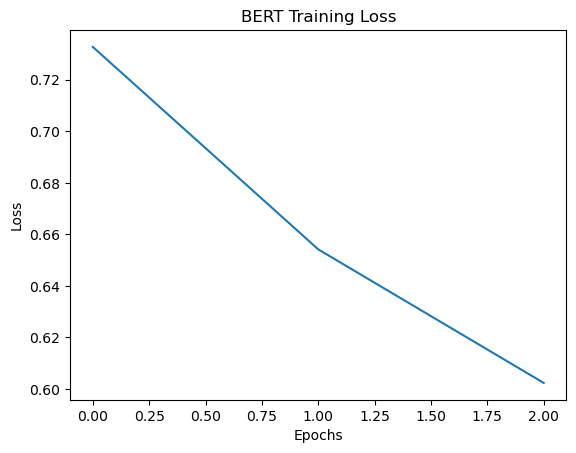

In [6]:
# Plot Loss
plt.plot(losses)
plt.title("BERT Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()